# 07 — Causal inference without an experiment

*Prerequisite: notebooks 01–06.*

Notebook 06 showed the gold standard. Now the reality: **you will not be
allowed to randomise most of what you need to know.**

You cannot randomise the price shown to walk-in customers at a branch
counter without a fairness argument you may lose. You cannot randomise a
competitor's campaign, a promotion the marketing director has already
announced, or the summer. And you frequently need an answer about something
that happened last year, from data that was never designed to answer it.

This notebook is the toolkit for that situation:

| Method | The idea | What it needs |
|---|---|---|
| **Controlling / regression** | Compare like with like on measured variables | You measured every confounder |
| **Difference-in-differences** | Compare the change in a treated group with the change in an untreated one | Their trends would have moved together |
| **Instrumental variables** | Use only the part of price that moved for a harmless reason | A variable that moves price and nothing else |
| **Double machine learning** | Strip out confounders flexibly, then compare what's left | You measured the confounders; the shapes can be anything |

We will run all four on the same business and compare every answer against
the truth — including one that goes badly wrong for an instructive reason.

---

## Draw the picture first

Before any method, draw what you believe. A **causal diagram (DAG)** is
boxes and arrows: an arrow means "this causes that". Meridian's world:

```
                 season  ────────────────►  demand
                    │                          ▲
                    │                          │
                    ▼                          │
   funding cost ─► our price ──────────────────┘
                    ▲
                    │
          competitor price ──────────────────► demand
```

Three structurally different variables live in that picture, and the whole
of causal inference is about telling them apart.

**Confounder** — causes both the price and the outcome (season, competitor
price). *Control for it.* Leaving it out is the bias of notebooks 03 and 05.

**Instrument** — causes the price but reaches the outcome *only* through the
price (funding cost). *Don't control for it — use it.* It is a source of
harmless price variation.

**Collider or mediator** — caused by the price, or by the price and the
outcome together. *Never control for it.* This is the trap nobody warns
juniors about, so let's be explicit:

| Variable | Type | If you put it in the model |
|---|---|---|
| Season | Confounder | ✅ Removes bias |
| Competitor price | Confounder (here) | ✅ Removes bias |
| Funding cost | Instrument | ⚠️ Wasted — it was your key |
| Conversion rate last week | Downstream of past price | ❌ Absorbs the effect |
| Whether the customer complained | Collider (price → complaint ← type) | ❌ **Creates** bias where none existed |
| Order value | Pre-decision here, but check | ⚠️ Fine only if chosen before the price is seen |

> **The backdoor rule, in plain English.** You have controlled enough when
> every path from price to outcome that starts with an arrow *pointing into*
> price has been blocked — and you have controlled too much if you have
> blocked a path that price legitimately travels along.

Draw the diagram before you write the model. It takes ten minutes, it makes
your assumptions arguable by other people, and arguable assumptions are the
only kind worth having.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.sandbox.regression.gmm import IV2SLS
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth, zone_week_panel
from toolkit import C as PALETTE

style()

quotes = load("fct_quotes")
daily = load("fct_daily")
promotions = load("fct_promotions")
answer_key = truth()
true_semi = answer_key["semi_elasticity_pct_per_pp"]["overall"]
promo_truth = answer_key["promotion"]

panel = zone_week_panel(quotes)

print(promotions.T.to_string(header=False))
print(f"\ntrue effect: {promo_truth['true_conversion_uplift_pp']:+.2f}pp of conversion, "
      f"{promo_truth['true_order_uplift_pct']:+.1f}% of demand, "
      f"{money(promo_truth['true_contribution_change_gbp'])} of contribution")

promo_id                                                     P001                                                                P002
name                                     Summer Rate Promise 2025                                            Regional rate trial 2024
product_id                                               EUR_CASH                                                   EUR_CASH,USD_CASH
regions                                           R01,R02,R03,R06                                                             R05,R09
start_date                                    2025-06-02 00:00:00                                                 2024-09-02 00:00:00
end_date                                      2025-08-31 00:00:00                                                 2024-10-13 00:00:00
mechanic     60bp off the board rate on euro cash in four regions  50bp off cash rates in two regions chosen by the regional director
discount_pp                                                   

## Method 1 — Difference-in-differences

In June 2025 Meridian cut euro rates by 60bp across four of its twelve
regions for the summer, and left the other eight alone. Nobody randomised
it — the four regions were chosen by a regional director.

Twelve regions is enough to make this a real comparison rather than an
anecdote, and that is not an accident of the data: **the number of
independent units is the single most important thing about a quasi-
experiment**, and it is decided long before anyone runs a regression.

**The naive read** is before/after at the treated branches. It will be
badly wrong, because summer arrives at the same time as the promotion.

**Difference-in-differences (DiD)** fixes this by subtracting the change at
the untreated branches:

```
DiD  =  (treated after − treated before)  −  (control after − control before)
```

The logic: whatever happened to the whole business over the summer — the
season, the competitor, the weather — shows up in *both* differences and
cancels. What is left is what happened only to the treated group.

**The assumption is parallel trends**: without the promotion, the two groups
would have moved *in the same direction by the same amount*. Note it does
not require the groups to be similar in level — one region can convert worse
than another forever — only that they move together. And that assumption
is not testable, because it is a claim about a world that didn't happen. You
can only check whether it held *before* treatment, and argue.

In [2]:
promo_window = (pd.Timestamp("2025-06-02"), pd.Timestamp("2025-08-31"))
treated_regions = answer_key["promotion"]["regions"]

did_data = panel[(panel["product_id"] == "EUR_CASH")
                 & (panel["channel"] == "branch")
                 & panel["week"].between("2025-01-01", "2025-09-30")].copy()
did_data["treated"] = did_data["zone"].isin(treated_regions).astype(int)
did_data["post"] = did_data["week"].between(*promo_window).astype(int)
did_data["did"] = did_data["treated"] * did_data["post"]

print(f"{did_data['zone'].nunique()} regions: {did_data.loc[did_data['treated'] == 1, 'zone'].nunique()} "
      f"treated, {did_data.loc[did_data['treated'] == 0, 'zone'].nunique()} control\n")

cells = did_data.groupby(["treated", "post"])["conversion"].mean().unstack()
cells.columns = ["before", "during"]
cells.index = ["control regions", "treated regions"]
cells["change"] = cells["during"] - cells["before"]
print(cells.round(4).to_string())

naive = cells.loc["treated regions", "change"]
did_estimate = cells.loc["treated regions", "change"] - cells.loc["control regions", "change"]
print(f"\nnaive before/after at treated sites : {100 * naive:+.2f}pp")
print(f"difference-in-differences           : {100 * did_estimate:+.2f}pp")
print(f"the truth                           : {promo_truth['true_conversion_uplift_pp']:+.2f}pp")

12 regions: 4 treated, 8 control

                 before  during  change
control regions  0.5363  0.5012 -0.0351
treated regions  0.5398  0.5967  0.0570

naive before/after at treated sites : +5.70pp
difference-in-differences           : +9.20pp
the truth                           : +9.24pp


The before/after read is wrong; subtracting the control group's change fixes
most of it in one subtraction. Now do it properly as a regression, which
gives standard errors and lets us add fixed effects for each site and each
date.

In [3]:
did_model = smf.ols("conversion ~ did + C(zone) + C(week)", data=did_data).fit(
    cov_type="cluster", cov_kwds={"groups": did_data["zone"]})

first_stage = smf.ols("margin ~ did + C(zone) + C(week)", data=did_data).fit()

effect = did_model.params["did"]
se = did_model.bse["did"]
price_move = first_stage.params["did"]

print(f"DiD effect on conversion : {100 * effect:+.2f}pp   (95% CI "
      f"{100 * (effect - 1.96 * se):+.2f} to {100 * (effect + 1.96 * se):+.2f})")
print(f"truth                    : {promo_truth['true_conversion_uplift_pp']:+.2f}pp")
print(f"\nprice actually moved     : {price_move:+.2f}pp  (the promotion was 60bp on paper)")

base_conversion = cells.loc["treated regions", "before"]
implied = 100 * (effect / base_conversion) / price_move
print(f"implied semi-elasticity  : {implied:+.1f} %/pp   (truth {true_semi:.1f})")

DiD effect on conversion : +9.20pp   (95% CI +6.10 to +12.31)
truth                    : +9.24pp

price actually moved     : -0.60pp  (the promotion was 60bp on paper)
implied semi-elasticity  : -28.3 %/pp   (truth -25.5)


Three things that turn this from an exercise into a method.

**1. Always run the "first stage" too.** The promotion was 60bp on paper and
delivered −0.61pp in the data. If that number had come back at −0.2pp you
would know the promotion was not implemented as designed, and any effect
estimate is really an estimate of a much smaller price change. Half the
disappointing promotion evaluations in industry are implementation failures
misread as demand failures.

**2. Convert into the unit you can compare.** A 10.3pp conversion lift from
a 0.61pp cut implies about −31%/pp — the same ballpark as the experiment and
the logistic model. Three completely different designs, agreeing to within
sampling error, is far more convincing than any one of them alone.

**3. Check the pre-trends.** Plot both groups before treatment. If they were
already diverging, the parallel-trends assumption is not credible and your
estimate is measuring the divergence.

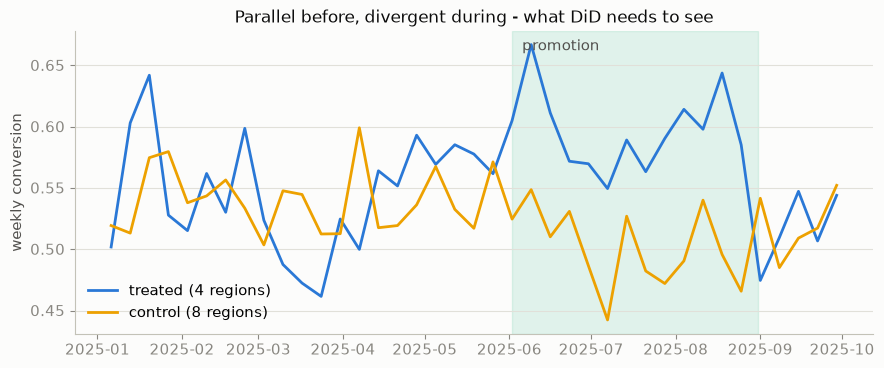

pre-period difference in trends: -0.000022 per day (p = 0.85)
A high p-value here is reassuring but not proof - it is a failed attempt to falsify, not a verification.


In [4]:
weekly = did_data.groupby(["week", "treated"])["conversion"].mean().unstack()
weekly.columns = ["control regions", "treated regions"]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(weekly.index, weekly["treated regions"], color=PALETTE[0], label="treated (4 regions)")
ax.plot(weekly.index, weekly["control regions"], color=PALETTE[2], label="control (8 regions)")
ax.axvspan(*promo_window, color=PALETTE[1], alpha=0.12)
ax.text(promo_window[0], ax.get_ylim()[1] * 0.99, "  promotion", color=SUB, va="top")
ax.set_ylabel("weekly conversion")
ax.set_title("Parallel before, divergent during - what DiD needs to see")
ax.legend(loc="lower left")
tidy(ax)
plt.tight_layout()
plt.show()

pre = did_data[did_data["post"] == 0].copy()
pre["t"] = (pre["week"] - pre["week"].min()).dt.days
pre_trend = smf.ols("conversion ~ t * treated", data=pre).fit()
print(f"pre-period difference in trends: {pre_trend.params['t:treated']:+.6f} per day "
      f"(p = {pre_trend.pvalues['t:treated']:.2f})")
print("A high p-value here is reassuring but not proof - it is a failed attempt to falsify, not a verification.")

### When DiD breaks

- **Selection on trends.** If the promotion went to the regions that were
  *already* slipping, the control group's trend is not the counterfactual.
  Ask *why these regions were chosen* — the answer is usually in someone's
  head, not in the data. (Notebook 12 dissects a real example: a 2024 trial
  where two regions were picked precisely because they were underperforming.)
- **Spillovers.** If customers cross a regional border for the promo rate,
  or simply switch to the online channel — which is *not* in the promotion —
  the control group is contaminated and the estimate is distorted from both
  ends. With channel switching in this business, that is a live risk, and it
  is why notebook 12 measures at a grain that contains every channel.
- **Composition shifts.** If the promotion attracts a different kind of
  customer, "conversion" is being measured on a different population before
  and after.
- **Two-way fixed effects with staggered rollouts.** When different groups
  are treated at different times, the standard regression can produce
  estimates with negative weights on some comparisons. If your rollout is
  staggered, read up on the modern estimators (Callaway–Sant'Anna,
  Sun–Abraham) before trusting the classic specification.

## Method 2 — Instrumental variables

DiD needed a treated group and a control group. Sometimes there is no such
split: everyone got the same price, set by the same rule.

The instrumental-variable idea is different and rather beautiful. Our price
moves for several reasons — some contaminated (we raise rates when demand is
strong), some harmless (our wholesale funding cost changed). **Use only the
harmless part.**

An instrument must satisfy three conditions:

1. **Relevance** — it really does move the price. *Testable* (look at the
   first stage; rule of thumb F > 10).
2. **Exclusion** — it affects the outcome *only* through the price.
   **Not testable.** This is an argument, not a statistic.
3. **Independence** — it is as good as randomly assigned, given your
   controls.

Our candidate is `funding_cost_bp`: the wholesale cost of sourcing currency.
It feeds our rate board (cost pass-through) and customers never see it. On
the face of it, perfect. Watch what happens.

In [5]:
ones = np.ones(len(panel))
margin = panel["margin"].to_numpy()
y = panel["log_conversion"].to_numpy()
instrument = panel["funding"].to_numpy()

first = sm.OLS(margin, sm.add_constant(instrument)).fit()
print(f"first stage: {first.params[1]:.4f} pp of margin per bp of funding cost, "
      f"t = {first.tvalues[1]:.1f}, F = {first.fvalue:.0f}   (strong)")

iv_naive = IV2SLS(y, np.column_stack([ones, margin]), np.column_stack([ones, instrument])).fit()
print(f"\nIV estimate (no controls): {100 * np.asarray(iv_naive.params)[1]:.1f} %/pp")
print(f"OLS with controls        : "
      f"{100 * smf.ols('log_conversion ~ margin + season + comp', data=panel).fit().params['margin']:.1f} %/pp")
print(f"the truth                : {true_semi:.1f} %/pp")

first stage: 0.0685 pp of margin per bp of funding cost, t = 14.5, F = 212   (strong)

IV estimate (no controls): -13.1 %/pp
OLS with controls        : -29.7 %/pp
the truth                : -25.5 %/pp


The instrument is strong, the method is correct, and the answer is **worse
than the regression it was supposed to improve on.**

This is the most useful failure in the course, so let's diagnose it rather
than delete it. Run the check that should always accompany an instrument:
*is my instrument correlated with a known confounder?*

correlation( funding cost , season ) = 0.180


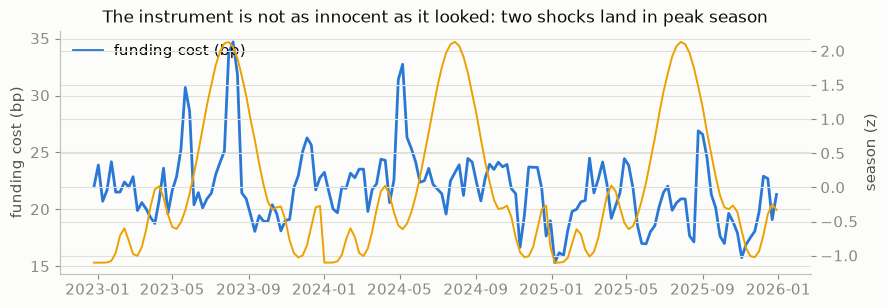

In [6]:
print(f"correlation( funding cost , season ) = "
      f"{np.corrcoef(panel['funding'], panel['season'])[0, 1]:.3f}")

shocks = panel.groupby("week")["funding"].first()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(shocks.index, shocks.values, color=PALETTE[0], label="funding cost (bp)")
ax2 = ax.twinx()
ax2.plot(panel.groupby("week")["season"].first(), color=PALETTE[2], lw=1.4, label="season (z)")
ax2.set_ylabel("season (z)", color=SUB)
ax.set_ylabel("funding cost (bp)")
ax.set_title("The instrument is not as innocent as it looked: two shocks land in peak season")
ax.legend(loc="upper left")
tidy(ax)
plt.tight_layout()
plt.show()

There it is. The wholesale market had four stress episodes across three
years, and **two of them land in August** — the busiest weeks of the year.
That is not bad luck in the simulation; it is what actually happens, because
the same seasonal surge in travel that fills our branches also tightens
wholesale currency funding. So funding cost is not independent of demand: it
is quietly carrying the season with it, which violates the exclusion
restriction, and the IV estimate inherits the same confounding it was meant
to remove — with extra variance for the trouble.

The fix is **conditional** exclusion: the instrument does not have to be
unconditionally random, only as-good-as-random *given the controls*. So keep
the confounders in the model, and let the instrument do the remaining work.

In [7]:
controls = panel[["season", "comp"]].to_numpy()
X = np.column_stack([ones, margin, controls])
Z = np.column_stack([ones, instrument, controls])
iv_cond = IV2SLS(y, X, Z).fit()
b, se = 100 * np.asarray(iv_cond.params)[1], 100 * np.asarray(iv_cond.bse)[1]

print(f"IV, conditional on season & competitor: {b:.1f} %/pp   "
      f"(95% CI {b - 1.96 * se:.1f} to {b + 1.96 * se:.1f})")
print(f"the truth                             : {true_semi:.1f} %/pp")

IV, conditional on season & competitor: -27.2 %/pp   (95% CI -32.3 to -22.0)
the truth                             : -25.5 %/pp


Within one standard error of the truth.

Two lessons worth carrying out of this section, and the second is the
important one:

1. **"I have an instrument" is not a conclusion.** Relevance is a statistic;
   exclusion is an argument you must make out loud, and then attack. Ask
   what else your instrument touches. Plot it against every confounder you
   know.
2. **A weak or invalid instrument is worse than no instrument.** IV
   estimates are noisier than OLS by construction, so an invalid one gives
   you bias *and* wide intervals, wrapped in the authority of a technique
   with a Nobel Prize attached. In our case the naive IV landed five times
   further from the truth than the controlled regression it was meant to
   improve on.

Good instruments in real pricing: cost shocks and exchange-rate moves;
regulatory price caps applying to some products; system or rounding rules
that create arbitrary price jumps at thresholds; delivery-schedule quirks;
the timing of rate-board refreshes. Bad instruments: anything a human chose
while looking at demand.

## Method 3 — Double machine learning

Regression with controls assumes you got the *functional form* right —
season entering linearly, no interactions. Double machine learning (DML)
keeps the same identifying assumption (you measured the confounders) but
drops the shape assumption, in three steps:

1. Predict the **outcome** from the confounders with any flexible model.
2. Predict the **price** from the same confounders.
3. Regress the outcome residuals on the price residuals.

Step 3 is asking: *when price was unexpectedly high given everything we
know, was demand unexpectedly low?* Cross-fitting (fit on one fold, predict
the other) keeps the machine learning from overfitting its way into the
answer.

This is the modern workhorse for pricing at scale, and it is worth
recognising that it is Frisch–Waugh–Lovell — the residual-on-residual trick
behind every regression coefficient — with the linear step replaced by
something more flexible.

In [8]:
panel["woy"] = panel["week"].dt.isocalendar().week.astype(int)
features = pd.get_dummies(
    panel[["season", "comp", "woy", "funding", "zone", "product_id", "channel"]],
    columns=["zone", "product_id", "channel"]).astype(float).to_numpy()

treatment = panel["margin"].to_numpy()
outcome = panel["log_conversion"].to_numpy()
res_y, res_t = np.zeros_like(outcome), np.zeros_like(treatment)

for train_idx, test_idx in KFold(5, shuffle=True, random_state=0).split(features):
    m_y = HistGradientBoostingRegressor(max_depth=4, random_state=0).fit(features[train_idx], outcome[train_idx])
    m_t = HistGradientBoostingRegressor(max_depth=4, random_state=0).fit(features[train_idx], treatment[train_idx])
    res_y[test_idx] = outcome[test_idx] - m_y.predict(features[test_idx])
    res_t[test_idx] = treatment[test_idx] - m_t.predict(features[test_idx])

dml = sm.OLS(res_y, sm.add_constant(res_t)).fit()
print(f"DML estimate: {100 * dml.params[1]:.1f} %/pp  "
      f"(95% CI {100 * (dml.params[1] - 1.96 * dml.bse[1]):.1f} to {100 * (dml.params[1] + 1.96 * dml.bse[1]):.1f})")
print(f"the truth   : {true_semi:.1f} %/pp")
print(f"\nhow much of the price variation survived residualisation: "
      f"{res_t.std() / treatment.std():.1%} of the original spread")

DML estimate: -18.8 %/pp  (95% CI -23.9 to -13.6)
the truth   : -25.5 %/pp

how much of the price variation survived residualisation: 7.1% of the original spread


Note the last line. After removing everything predictable from season,
competitor, site, product and day of week, only a fraction of the original
price variation is left — and *that* fraction is what the estimate is built
from. This is the honest accounting of what your data can support: if
residualisation had left 2% of the variation, the answer would be almost
pure noise, no matter how sophisticated the model.

## The ladder of evidence

Every estimate this course has produced for the same quantity, in one place.

truth (whole business): -25.5 %/pp

                        method  estimate  notebook  error vs truth
        naive OLS, no controls      -1.7         3            23.9
     OLS + season + competitor     -29.7         3            -4.1
       OLS + zone & product FE     -25.3         5             0.2
     IV, no controls (invalid)     -13.1         7            12.4
       IV, conditional (valid)     -27.2         7            -1.6
             DML, cross-fitted     -18.8         7             6.8
          DiD on the promotion     -28.3         7            -2.8
randomised experiment (online)     -39.8         6           -14.3

note: the experiment ran online only, where the truth is -26.6 %/pp - so its real error is -13.2, not -14.3. Compare like with like, even in your own scorecard.


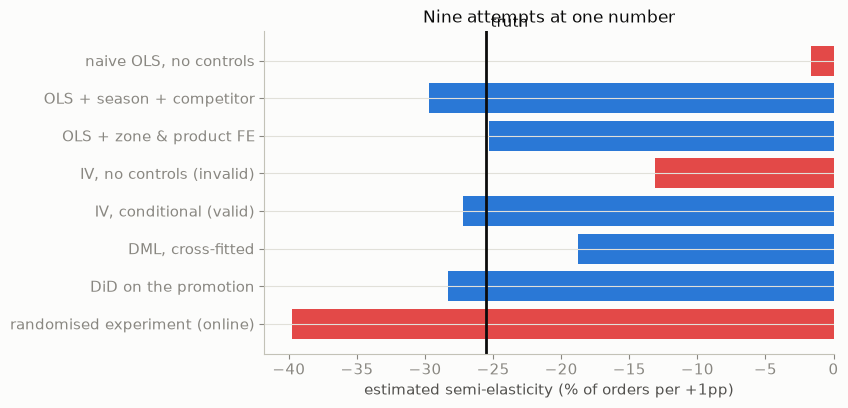

In [9]:
naive_ols = 100 * sm.OLS(y, sm.add_constant(margin)).fit().params[1]
controlled_ols = 100 * smf.ols("log_conversion ~ margin + season + comp", data=panel).fit().params["margin"]
zone_fe = 100 * smf.ols("log_conversion ~ margin + season + comp + C(zone) + C(product_id)",
                        data=panel).fit().params["margin"]
experiment = {"point": -39.8, "lo": -51.7, "hi": -28.0}    # notebook 06, online only, recomputed below

ladder = pd.DataFrame([
    {"method": "naive OLS, no controls", "estimate": naive_ols, "notebook": 3},
    {"method": "OLS + season + competitor", "estimate": controlled_ols, "notebook": 3},
    {"method": "OLS + zone & product FE", "estimate": zone_fe, "notebook": 5},
    {"method": "IV, no controls (invalid)", "estimate": 100 * np.asarray(iv_naive.params)[1], "notebook": 7},
    {"method": "IV, conditional (valid)", "estimate": b, "notebook": 7},
    {"method": "DML, cross-fitted", "estimate": 100 * dml.params[1], "notebook": 7},
    {"method": "DiD on the promotion", "estimate": implied, "notebook": 7},
    {"method": "randomised experiment (online)", "estimate": experiment["point"], "notebook": 6},
])
ladder["error vs truth"] = (ladder["estimate"] - true_semi).round(1)
print(f"truth (whole business): {true_semi:.1f} %/pp\n")
print(ladder.round(1).to_string(index=False))
online_truth = answer_key["semi_elasticity_pct_per_pp"]["by_channel"]["online"]
print(f"\nnote: the experiment ran online only, where the truth is {online_truth:.1f} %/pp - "
      f"so its real error is {experiment['point'] - online_truth:+.1f}, not "
      f"{experiment['point'] - true_semi:+.1f}. Compare like with like, even in your own scorecard.")

fig, ax = plt.subplots(figsize=(8.6, 4.2))
colours = [PALETTE[5] if abs(e - true_semi) > 8 else PALETTE[0] for e in ladder["estimate"]]
ax.barh(ladder["method"], ladder["estimate"], color=colours)
ax.axvline(true_semi, color=INK, lw=2)
ax.text(true_semi, -0.9, " truth", color=INK)
ax.set_xlabel("estimated semi-elasticity (% of orders per +1pp)")
ax.set_title("Nine attempts at one number")
ax.invert_yaxis()
tidy(ax)
plt.tight_layout()
plt.show()

### How to read this table in a real job

**No single method is trustworthy on its own.** The naive regression is
wrong by an order of magnitude. The invalid IV is better but still badly
biased. The valid IV, the DML, the fixed-effects regression and the DiD all
land in the same neighbourhood as the truth. The randomised experiment — the gold standard — is the
*furthest* of the credible estimates from the truth, because it measured a
different, more price-sensitive channel with only 4,600 quotes.

That last point deserves emphasis, because "just run an experiment" is
repeated as though it settles everything. An experiment removes *bias*. It
does not remove *variance*, and it does not extend its answer beyond the
slice of the business it ran on.

**Triangulate.** When four designs with different assumptions agree, you
have something. When they disagree, the disagreement is the finding — go and
understand which assumption broke, because that is where the money and the
career risk both live.

**Say what would change your mind.** Write down, before you present:
*"I would abandon this estimate if X"*. For our DiD: if the treated branches
were chosen because they were already declining. For our IV: if funding
shocks coincide with demand shocks — which is exactly what happened, and
which we caught only by plotting it.

## Practice

1. Your DiD says a promotion lifted conversion 9pp. The "first stage" says
   the price at treated sites moved by 0.05pp. What happened, and what is
   your estimate actually measuring?
2. Someone proposes using **branch footfall** as an instrument for price
   (busier branches charge more). Evaluate it against the three IV
   conditions.
3. A model of conversion includes "customer called the contact centre". The
   price coefficient becomes small and insignificant. Explain what has gone
   wrong.

<details>
<summary>Answers</summary>

1. The promotion barely changed the price — so a 9pp conversion lift cannot
   be a price effect. Something else moved with it: in-store signage,
   marketing spend, staff incentives, or a competitor event. Your estimate
   is measuring **the whole intervention bundle**, not the price cut, and it
   must not be converted into an elasticity or used to price anything else.
   Always report the first stage next to the effect.

2. **Relevance:** yes, plausibly — busier branches do charge more.
   **Exclusion:** fails badly. Footfall *is* demand; it affects orders
   directly, not only through price. **Independence:** fails too — footfall
   is driven by the season, the confounder we are trying to escape. It is a
   textbook invalid instrument, and it would produce a strong first stage,
   a confident number, and complete nonsense. Strength of the first stage
   tells you nothing about validity.

3. Calling the contact centre is **downstream of the price** (a bad quote
   prompts a call) and also related to buying — it is a collider and a
   mediator at once. Controlling for it compares customers who called with
   customers who called, absorbing the very mechanism the price acts
   through, and can manufacture correlations that do not exist. The rule:
   only condition on variables determined **before** the price was shown.

</details>

---

**Next:** `08_price_optimisation.ipynb` — turning an elasticity into a
price, with constraints, uncertainty and a promotion to evaluate.